<a href="https://colab.research.google.com/github/Tanukashyap28/DecisionTreeHandsOn/blob/main/hands__on__decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
dataframe= pd.read_csv("/content/WineQT.csv")

In [ ]:
dataframe.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


here quality is the target block

In [ ]:
dataframe.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
dataframe["quality"].value_counts()

,count
quality,
5,483
6,462
7,143
4,33
8,16
3,6


read as...483 people rate 5

EDA perform

In [ ]:
dataframe.dtypes

,0
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


In [ ]:
# checking missing value
dataframe.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
dataframe.head(20)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.600,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.650,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.580,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,6.7,0.580,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5


In [ ]:
dataframe.shape

(1143, 12)

total ecords is 1143
target is quality(3,4,5,6,7,8)->supervised decision tree will use



In [ ]:
# correation coefficient
dataframe.corr()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.250728,0.673157,0.171831,0.107889,-0.164831,-0.110628,0.681501,-0.685163,0.174592,-0.075055,0.121970
volatile acidity,-0.250728,1.000000,-0.544187,-0.005751,0.056336,-0.001962,0.077748,0.016512,0.221492,-0.276079,-0.203909,-0.407394
citric acid,0.673157,-0.544187,1.000000,0.175815,0.245312,-0.057589,0.036871,0.375243,-0.546339,0.331232,0.106250,0.240821
residual sugar,0.171831,-0.005751,0.175815,1.000000,0.070863,0.165339,0.190790,0.380147,-0.116959,0.017475,0.058421,0.022002
chlorides,0.107889,0.056336,0.245312,0.070863,1.000000,0.015280,0.048163,0.208901,-0.277759,0.374784,-0.229917,-0.124085
free sulfur dioxide,-0.164831,-0.001962,-0.057589,0.165339,0.015280,1.000000,0.661093,-0.054150,0.072804,0.034445,-0.047095,-0.063260
total sulfur dioxide,-0.110628,0.077748,0.036871,0.190790,0.048163,0.661093,1.000000,0.050175,-0.059126,0.026894,-0.188165,-0.183339
density,0.681501,0.016512,0.375243,0.380147,0.208901,-0.054150,0.050175,1.000000,-0.352775,0.143139,-0.494727,-0.175208
pH,-0.685163,0.221492,-0.546339,-0.116959,-0.277759,0.072804,-0.059126,-0.352775,1.000000,-0.185499,0.225322,-0.052453
sulphates,0.174592,-0.276079,0.331232,0.017475,0.374784,0.034445,0.026894,0.143139,-0.185499,1.000000,0.094421,0.257710


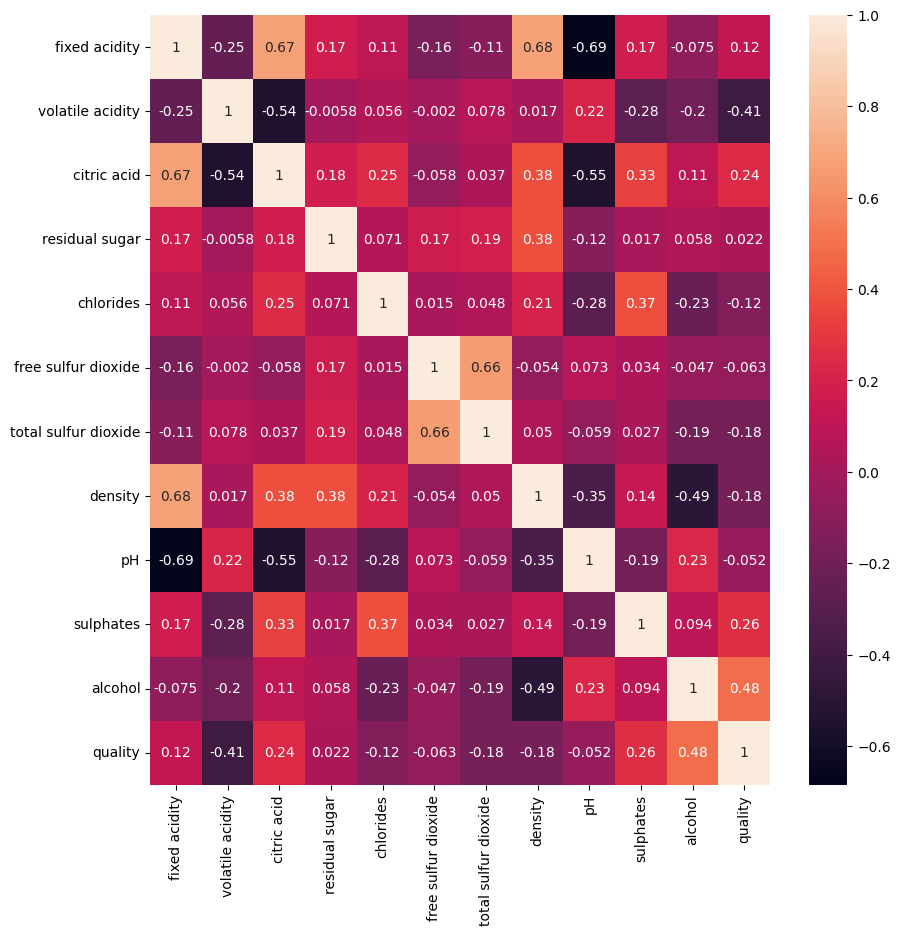

In [ ]:
plt.figure(figsize=(10,10))
ax=sns.heatmap(dataframe.corr(),annot=True)
plt.show()

In [ ]:
# descriptive statistics
dataframe.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
cols=dataframe.columns


In [ ]:
cols

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

/tmp/ipython-input-3358959127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe[col])


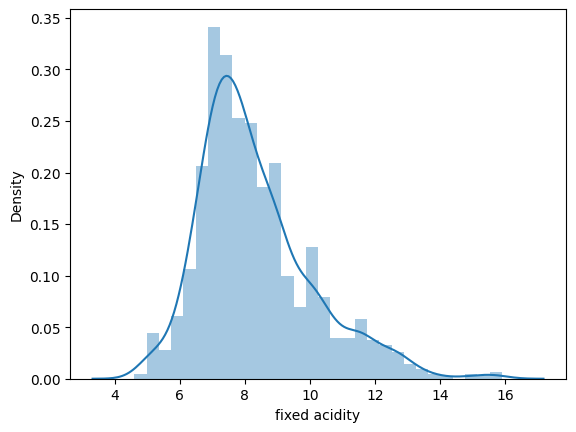

/tmp/ipython-input-3358959127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe[col])


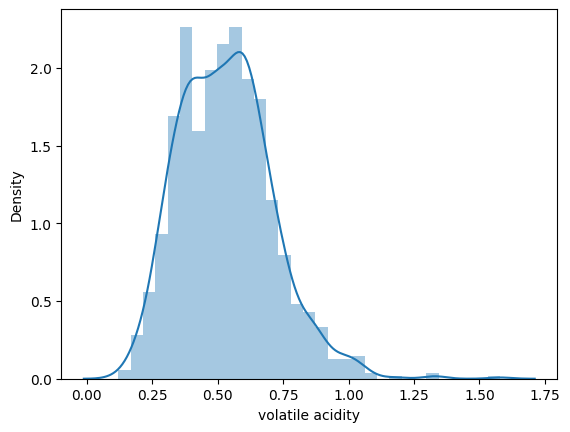

/tmp/ipython-input-3358959127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe[col])


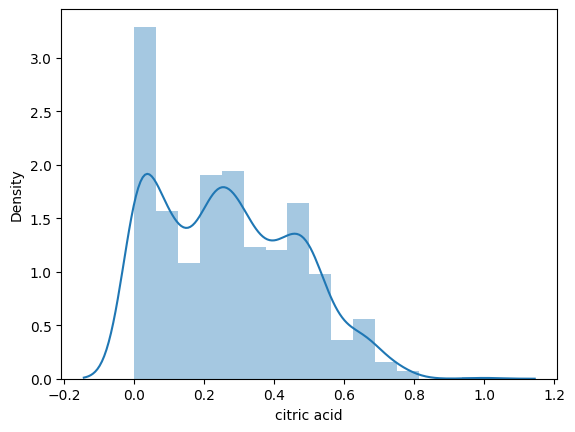

/tmp/ipython-input-3358959127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe[col])


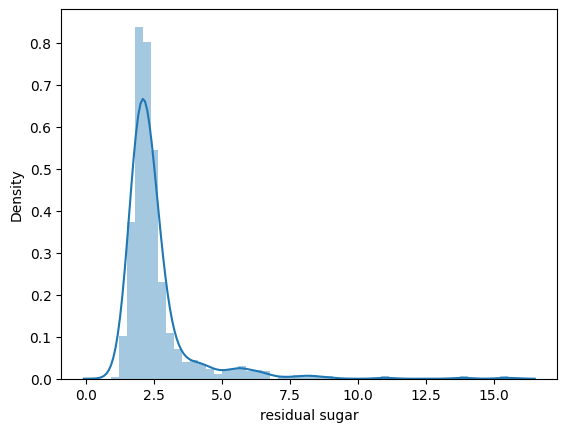

/tmp/ipython-input-3358959127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe[col])


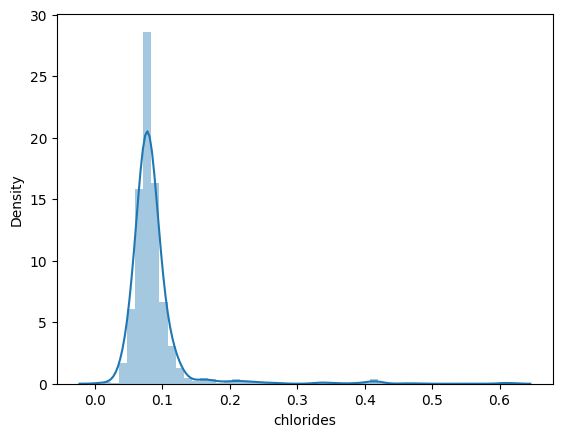

/tmp/ipython-input-3358959127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe[col])


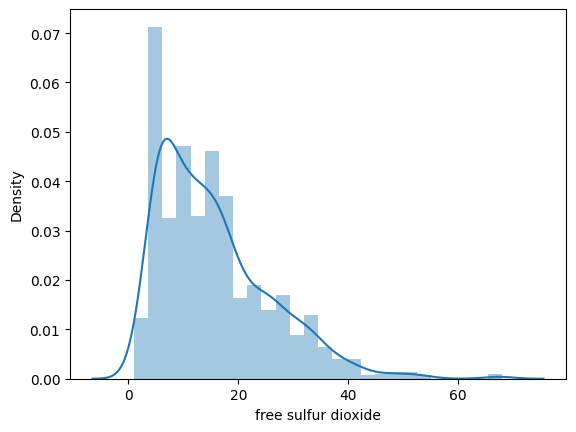

/tmp/ipython-input-3358959127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe[col])


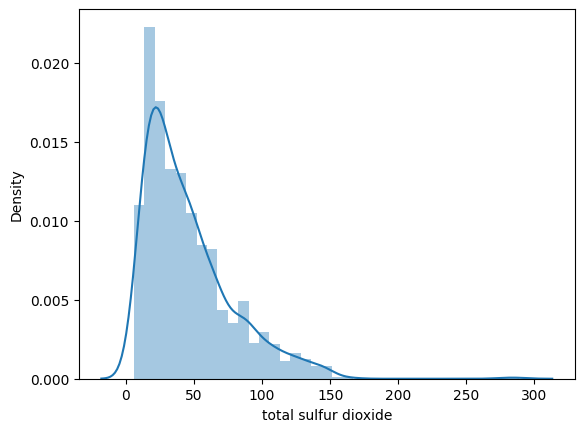

/tmp/ipython-input-3358959127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe[col])


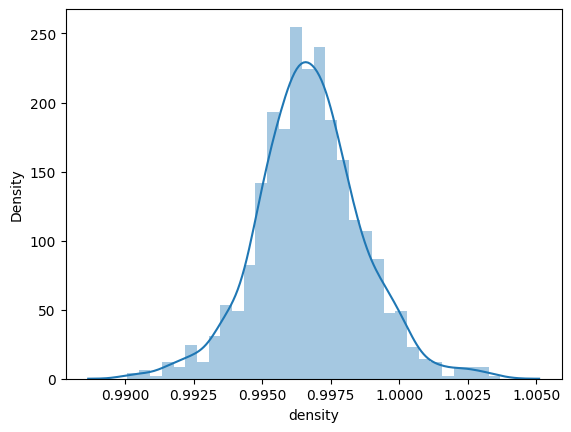

/tmp/ipython-input-3358959127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe[col])


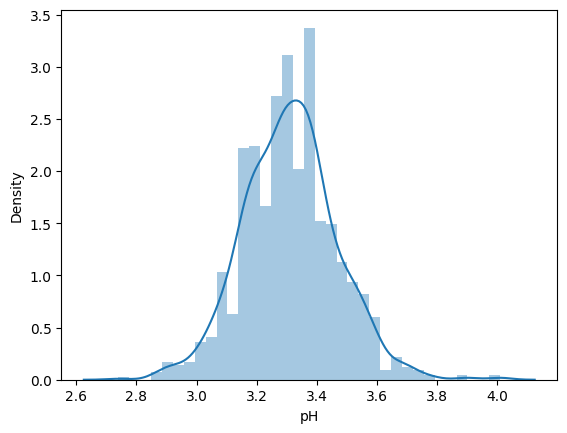

/tmp/ipython-input-3358959127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe[col])


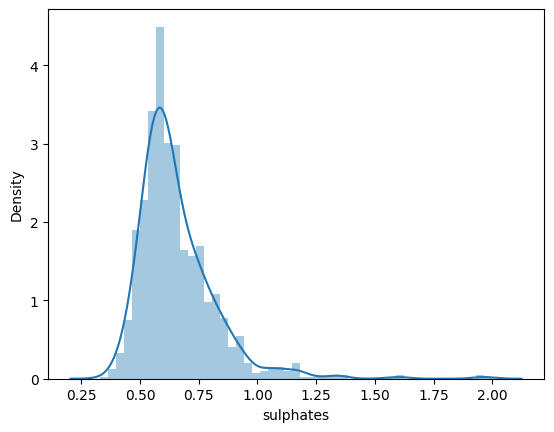

/tmp/ipython-input-3358959127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe[col])


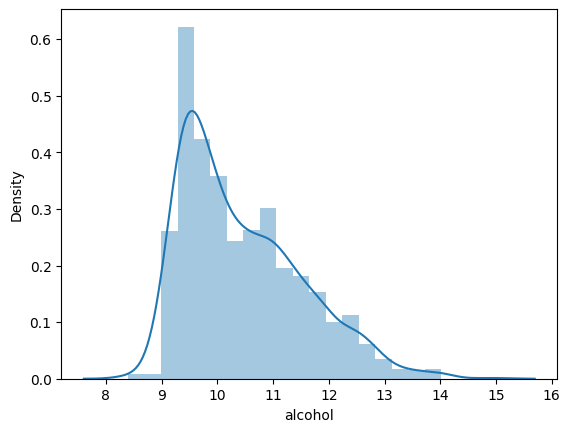

/tmp/ipython-input-3358959127.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataframe[col])


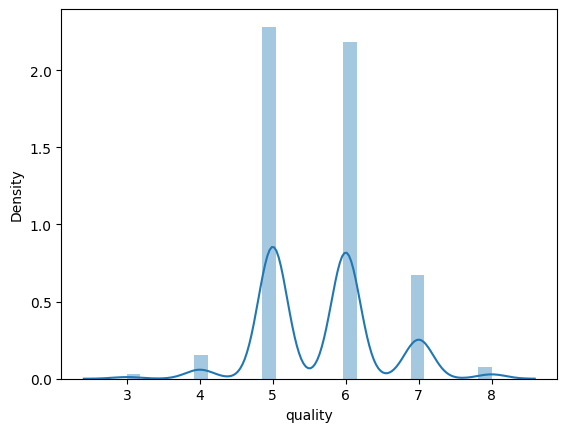

In [ ]:
for col in cols:
  sns.distplot(dataframe[col])
  plt.show()

In [ ]:
# x->input feature and y->target feature
x=dataframe.drop(columns="quality",axis=1)
y=dataframe["quality"]

In [ ]:
y

,quality
0,5
1,5
2,5
3,6
4,5
...,...
1138,6
1139,6
1140,5
1141,6


<Axes: >

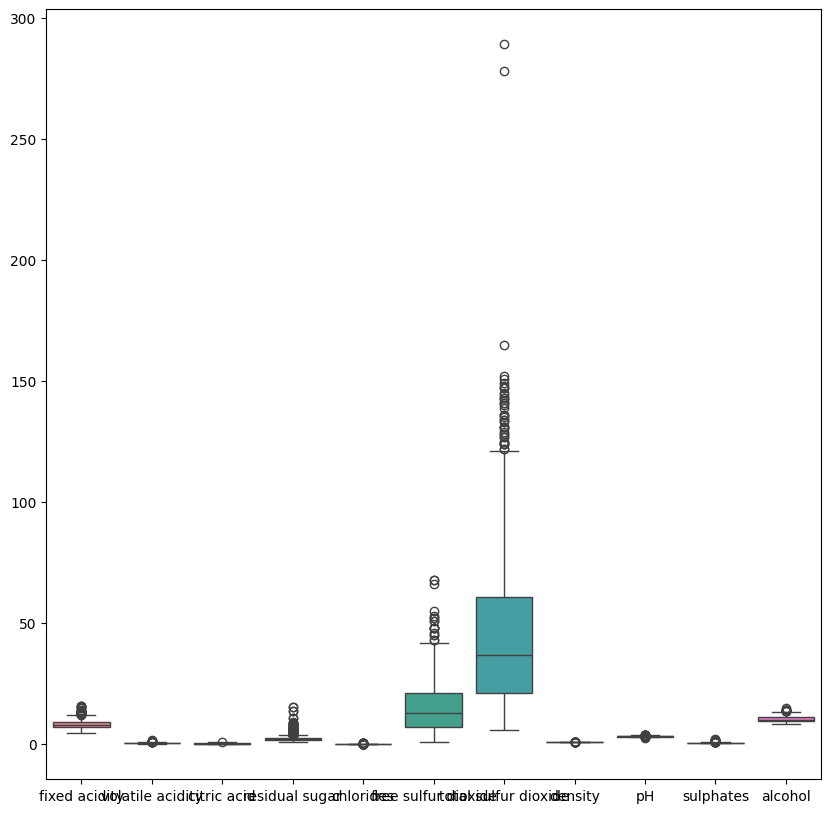

In [ ]:
# outlier detection
# boxplot
fig,ax=plt.subplots(figsize=(10,10))
sns.boxplot(data=x,ax=ax)

In [ ]:
dataframe.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
# remove outlier
cols=['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar','chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol']
x_outlier_detection=x
y_outlier_detection=y
for col in cols:
  q1=x[col].quantile(0.25)
  q3=x[col].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  # create mask on original data
  mask=(x[col]>=lower_bound)&(x[col]<=upper_bound)
  mask=mask.loc[x_outlier_detection.index]
  # apply mask
  x_outlier_detection=x_outlier_detection[mask]
  y_outlier_detection=y_outlier_detection[mask]
  for idx,name in enumerate(mask.value_counts().index.tolist()):
      print(f"for{col},{name}->{mask.value_counts().iloc[idx]}")



forfixed acidity,True->1099
forfixed acidity,False->44
forvolatile acidity,True->1085
forvolatile acidity,False->14
forcitric acid,True->1084
forcitric acid,False->1
forresidual sugar,True->987
forresidual sugar,False->97
forchlorides,True->925
forchlorides,False->62
forfree sulfur dioxide,True->915
forfree sulfur dioxide,False->10
fortotal sulfur dioxide,True->885
fortotal sulfur dioxide,False->30
fordensity,True->874
fordensity,False->11
forpH,True->865
forpH,False->9
forsulphates,True->850
forsulphates,False->15
foralcohol,True->848
foralcohol,False->2


In [ ]:
x_outlier_detection.shape

(848, 11)

In [ ]:
x_outlier_detection.info()


<class 'pandas.core.frame.DataFrame'>
Index: 848 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         848 non-null    float64
 1   volatile acidity      848 non-null    float64
 2   citric acid           848 non-null    float64
 3   residual sugar        848 non-null    float64
 4   chlorides             848 non-null    float64
 5   free sulfur dioxide   848 non-null    float64
 6   total sulfur dioxide  848 non-null    float64
 7   density               848 non-null    float64
 8   pH                    848 non-null    float64
 9   sulphates             848 non-null    float64
 10  alcohol               848 non-null    float64
dtypes: float64(11)
memory usage: 79.5 KB


<Axes: >

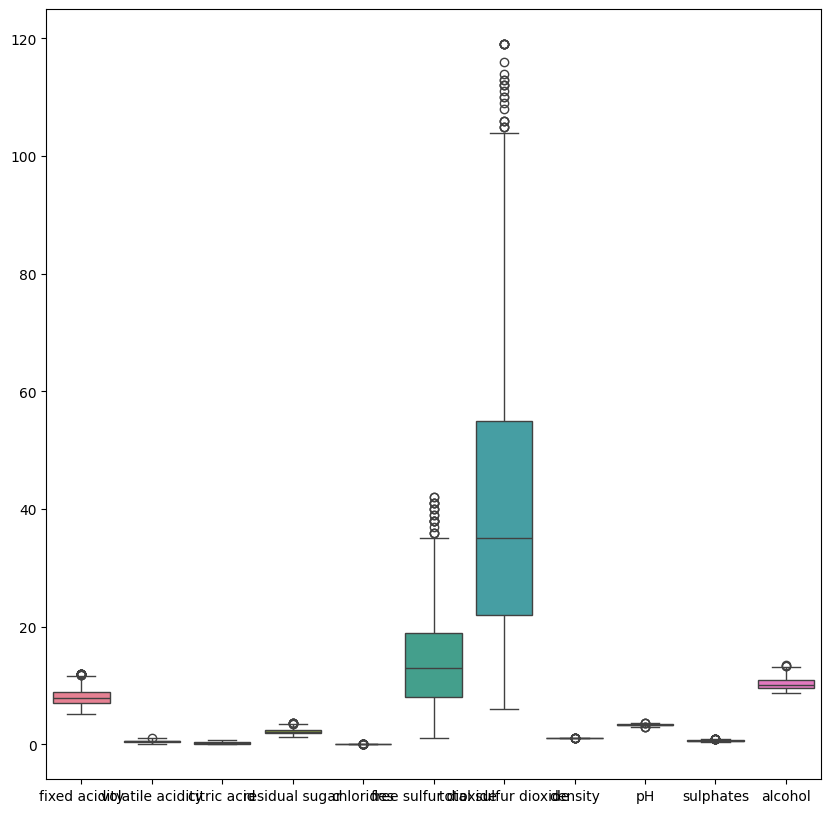

In [ ]:
fig,ax=plt.subplots(figsize=(10,10))
sns.boxplot(data=x_outlier_detection,ax=ax)

In [ ]:
# scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x_outlier_detection)

<Axes: >

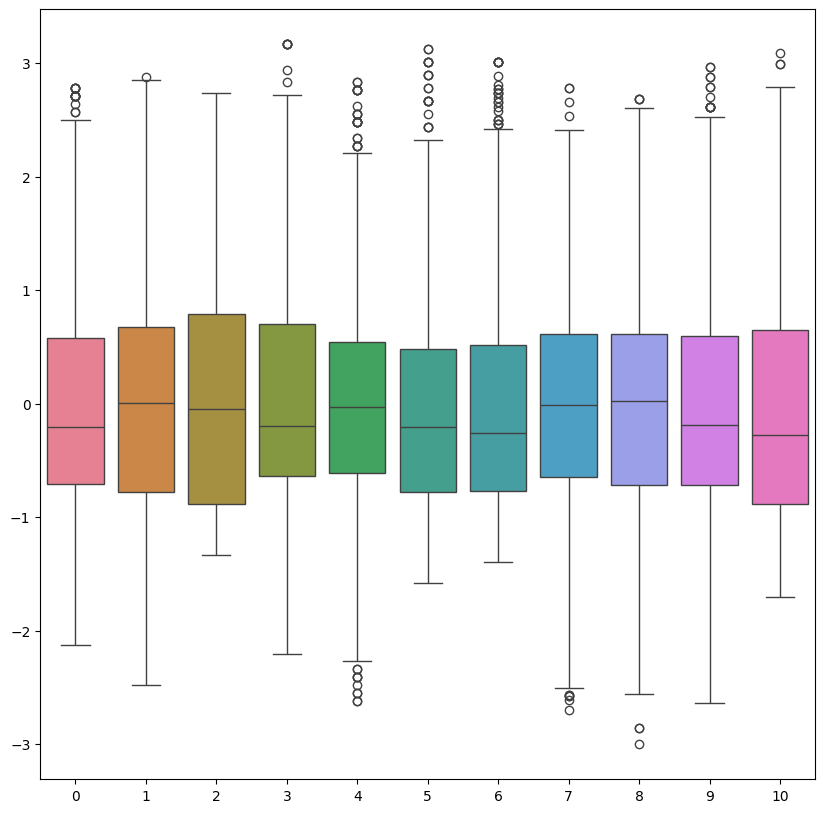

In [ ]:
fig,ax=plt.subplots(figsize=(10,10))
sns.boxplot(data=x_scaled,ax=ax)

In [ ]:
type(x_scaled)

numpy.ndarray

In [ ]:
x_scaled=pd.DataFrame(x_scaled,columns=cols)

In [ ]:
x_scaled.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,8.480000e+02,8.480000e+02,8.480000e+02,8.480000e+02,8.480000e+02,8.480000e+02,8.480000e+02,8.480000e+02,8.480000e+02,8.480000e+02,8.480000e+02
mean,5.697748e-16,-3.351617e-17,-1.382542e-16,3.351617e-17,4.692263e-16,-9.216946e-17,7.541138e-17,-2.882390e-15,-4.650368e-15,1.759599e-16,-6.703233e-16
std,1.000590e+00,1.000590e+00,1.000590e+00,1.000590e+00,1.000590e+00,1.000590e+00,1.000590e+00,1.000590e+00,1.000590e+00,1.000590e+00,1.000590e+00
min,-2.130114e+00,-2.477729e+00,-1.331561e+00,-2.210626e+00,-2.619186e+00,-1.582222e+00,-1.392428e+00,-2.702606e+00,-3.001945e+00,-2.641192e+00,-1.700728e+00
25%,-7.059512e-01,-7.827207e-01,-8.859556e-01,-6.427573e-01,-6.100062e-01,-7.790006e-01,-7.698594e-01,-6.457066e-01,-7.138868e-01,-7.146924e-01,-8.850997e-01
50%,-2.074944e-01,4.247515e-03,-5.044587e-02,-1.947949e-01,-3.345886e-02,-2.052708e-01,-2.640226e-01,-9.937566e-03,2.419660e-02,-1.892835e-01,-2.733788e-01
75%,5.757949e-01,6.701437e-01,7.850639e-01,7.011298e-01,5.430885e-01,4.832050e-01,5.141879e-01,6.164819e-01,6.146633e-01,5.988298e-01,6.442025e-01
max,2.783247e+00,2.879708e+00,2.734587e+00,3.164923e+00,2.831807e+00,3.122362e+00,3.004462e+00,2.782460e+00,2.681297e+00,2.963170e+00,3.091086e+00


model training


In [ ]:
# split in test and train
dataNew=dataframe.loc[y_outlier_detection.index]


In [ ]:
print(f"shape of x:{x_scaled.shape}")
print(f"shape of y:{y_outlier_detection.shape}")

shape of x:(848, 11)
shape of y:(848,)


In [ ]:
# split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y_outlier_detection,test_size=0.33,random_state=42)

In [ ]:
x_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
286,1.786333,-1.327545,1.397771,0.029186,-1.081727,0.368459,-0.069470,0.663230,-1.378162,-1.064965,-0.579239
311,-0.349911,-0.722185,-0.551752,1.821036,0.595502,0.712697,0.047262,-0.084734,-0.049612,-0.539556,0.134435
544,0.077338,1.275504,-0.830255,-0.418776,-0.802189,-1.123238,-1.236786,-1.468467,-0.344845,-0.539556,1.459830
24,0.006130,-0.903793,0.228057,-0.194795,-0.872073,-0.205271,-0.458575,0.164587,-0.713887,0.861534,-0.681193
746,-0.421119,-0.782721,-0.328949,-1.314701,0.036426,1.056935,0.630919,-0.022404,0.098005,-0.451988,-0.987053
...,...,...,...,...,...,...,...,...,...,...,...
71,-1.774073,-0.177361,-0.830255,0.253167,-2.060110,0.253713,2.226251,-1.767652,2.238447,-0.014147,2.683272
106,-0.563535,0.306928,0.339459,0.477149,-0.312997,0.024221,0.514188,0.164587,0.983705,-0.364420,-0.171425
270,0.860627,1.124164,0.005255,-0.194795,-0.592535,-1.123238,-0.847680,0.039927,-1.525778,-0.364420,-0.477286
435,-0.421119,-0.661649,0.450860,1.149092,-0.802189,-0.893747,-0.653128,-0.159530,-0.640078,-1.677942,0.032482


In [ ]:
y_train.value_counts()

,count
quality,
5,245
6,235
7,61
4,17
8,8
3,2


In [ ]:
# imbalace data(smote)
from imblearn.over_sampling import RandomOverSampler

# Use RandomOverSampler instead of SMOTE
ros = RandomOverSampler(random_state=42)

x_train_resampled, y_train_resampled = ros.fit_resample(x_train, y_train)

print("Resampled class distribution:")
print(pd.Series(y_train_resampled).value_counts())

# cant apply smote because quality 3 has only 2 row
# from imblearn.over_sampling import SMOTE
# smote=SMOTE(random_state=42)
# x_train_resampled,y_train_resampled=smote.fit_resample(x_train,y_train)
# print("resample class classification")
# print(pd.Series(y_train_resampled).value_counts())

Resampled class distribution:
quality
6    245
7    245
5    245
4    245
8    245
3    245
Name: count, dtype: int64


model training

In [ ]:
# from sklearn.tree import DecisionTreeClassifier
# model=DecisionTreeClassifier()
# model.fit(x_train_resampled,y_train_resampled)

from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred=model.predict(x_test)
print(y_pred)

[6 5 5 6 6 5 5 7 5 7 5 5 6 6 5 8 5 6 5 6 6 5 5 5 5 6 6 8 7 5 6 6 6 5 7 5 8
 5 5 5 6 5 5 7 6 6 7 7 5 6 6 5 5 6 5 7 5 6 6 5 5 6 5 5 6 7 5 6 6 7 5 5 5 5
 6 6 6 5 5 5 6 5 6 5 5 5 5 6 6 6 6 7 6 8 5 5 6 6 4 5 8 6 5 5 5 6 6 5 5 5 5
 6 7 5 6 6 5 6 5 5 6 5 5 6 5 5 5 5 6 7 5 5 5 5 5 6 6 6 5 6 5 6 5 6 6 6 7 5
 6 5 5 6 6 6 5 7 5 6 5 7 6 5 6 6 5 6 7 7 6 7 5 4 6 6 6 7 5 7 7 7 5 8 6 6 6
 5 8 5 5 6 7 5 5 5 7 5 5 6 6 7 6 6 5 5 6 7 5 5 6 5 5 6 5 6 6 6 6 6 6 7 6 5
 6 5 5 6 5 6 5 6 5 6 6 5 5 6 6 5 6 6 5 5 5 6 5 5 5 6 6 5 6 5 6 6 5 7 6 6 6
 5 6 6 6 6 5 6 7 5 7 5 5 6 6 6 7 5 5 6 6 6]


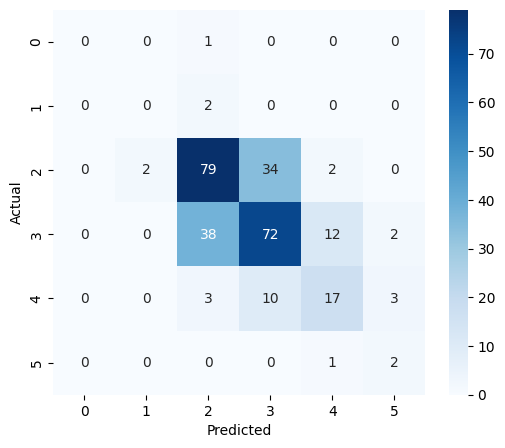

In [ ]:
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it nicely
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         2
           5       0.64      0.68      0.66       117
           6       0.62      0.58      0.60       124
           7       0.53      0.52      0.52        33
           8       0.29      0.67      0.40         3

    accuracy                           0.61       280
   macro avg       0.35      0.41      0.36       280
weighted avg       0.61      0.61      0.61       280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
train_score = model.score(x_train_resampled, y_train_resampled)
test_score = model.score(x_test, y_test)

print(f"Training Accuracy: {train_score*100:.2f}%")
print(f"Testing Accuracy:  {test_score*100:.2f}%")



Training Accuracy: 100.00%
Testing Accuracy:  60.71%


[Text(0.5638197431680162, 0.975, 'x[10] <= 0.593\ngini = 0.833\nsamples = 1470\nvalue = [245, 245, 245, 245, 245, 245]'),
 Text(0.37561519483805667, 0.925, 'x[1] <= 2.713\ngini = 0.781\nsamples = 926\nvalue = [245, 214, 220, 164, 83, 0]'),
 Text(0.46971746900303646, 0.95, 'True  '),
 Text(0.31293332489878545, 0.875, 'x[7] <= 2.595\ngini = 0.778\nsamples = 799\nvalue = [121.0, 214.0, 218.0, 163.0, 83.0, 0.0]'),
 Text(0.21995824898785424, 0.825, 'x[6] <= -1.062\ngini = 0.724\nsamples = 677\nvalue = [0, 214, 217, 163, 83, 0]'),
 Text(0.05344129554655871, 0.775, 'x[8] <= -0.308\ngini = 0.414\nsamples = 127\nvalue = [0, 95, 14, 15, 3, 0]'),
 Text(0.019433198380566803, 0.725, 'x[9] <= 1.212\ngini = 0.586\nsamples = 16\nvalue = [0, 0, 4, 9, 3, 0]'),
 Text(0.012955465587044534, 0.675, 'x[0] <= -0.314\ngini = 0.426\nsamples = 13\nvalue = [0, 0, 4, 9, 0, 0]'),
 Text(0.006477732793522267, 0.625, 'gini = 0.0\nsamples = 2\nvalue = [0, 0, 2, 0, 0, 0]'),
 Text(0.019433198380566803, 0.625, 'x[8] <= -1

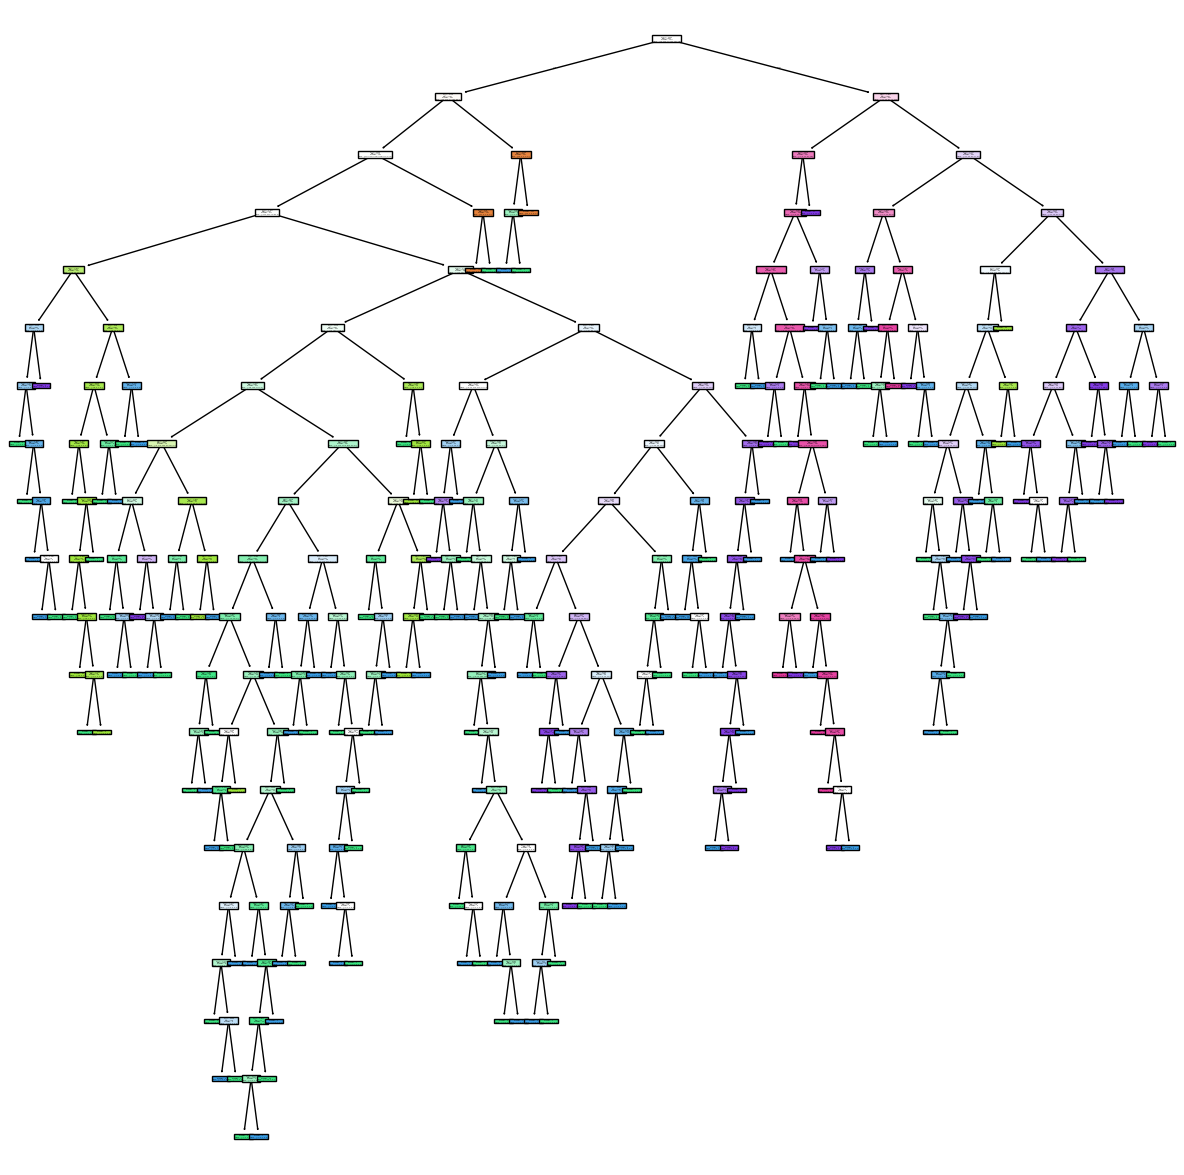

In [ ]:
# making decision tree
from sklearn import tree
plt.figure(figsize=(15,15))
tree.plot_tree(model,filled=True)

In [ ]:

x_sampleData = x_train_resampled.head()
x_sampleData  # <--- Add this line



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,1.786333,-1.327545,1.397771,0.029186,-1.081727,0.368459,-0.069470,0.663230,-1.378162,-1.064965,-0.579239
1,-0.349911,-0.722185,-0.551752,1.821036,0.595502,0.712697,0.047262,-0.084734,-0.049612,-0.539556,0.134435
2,0.077338,1.275504,-0.830255,-0.418776,-0.802189,-1.123238,-1.236786,-1.468467,-0.344845,-0.539556,1.459830
3,0.006130,-0.903793,0.228057,-0.194795,-0.872073,-0.205271,-0.458575,0.164587,-0.713887,0.861534,-0.681193
4,-0.421119,-0.782721,-0.328949,-1.314701,0.036426,1.056935,0.630919,-0.022404,0.098005,-0.451988,-0.987053


In [ ]:
y_sampleData=y_train_resampled.head()
y_sampleData

,quality
0,6
1,6
2,6
3,7
4,5


In [ ]:

sampleModel = DecisionTreeClassifier()
sampleModel.fit(x_sampleData, y_sampleData)

DecisionTreeClassifier()

In [ ]:
y_sampleData.value_counts()

,count
quality,
6,3
7,1
5,1


In [ ]:
x_sampleData.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol'],
      dtype='object')

[Text(0.4, 0.8333333333333334, 'x[9] <= -0.496\ngini = 0.56\nsamples = 5\nvalue = [1, 3, 1]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[3] <= -0.755\ngini = 0.5\nsamples = 2\nvalue = [1, 0, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]')]

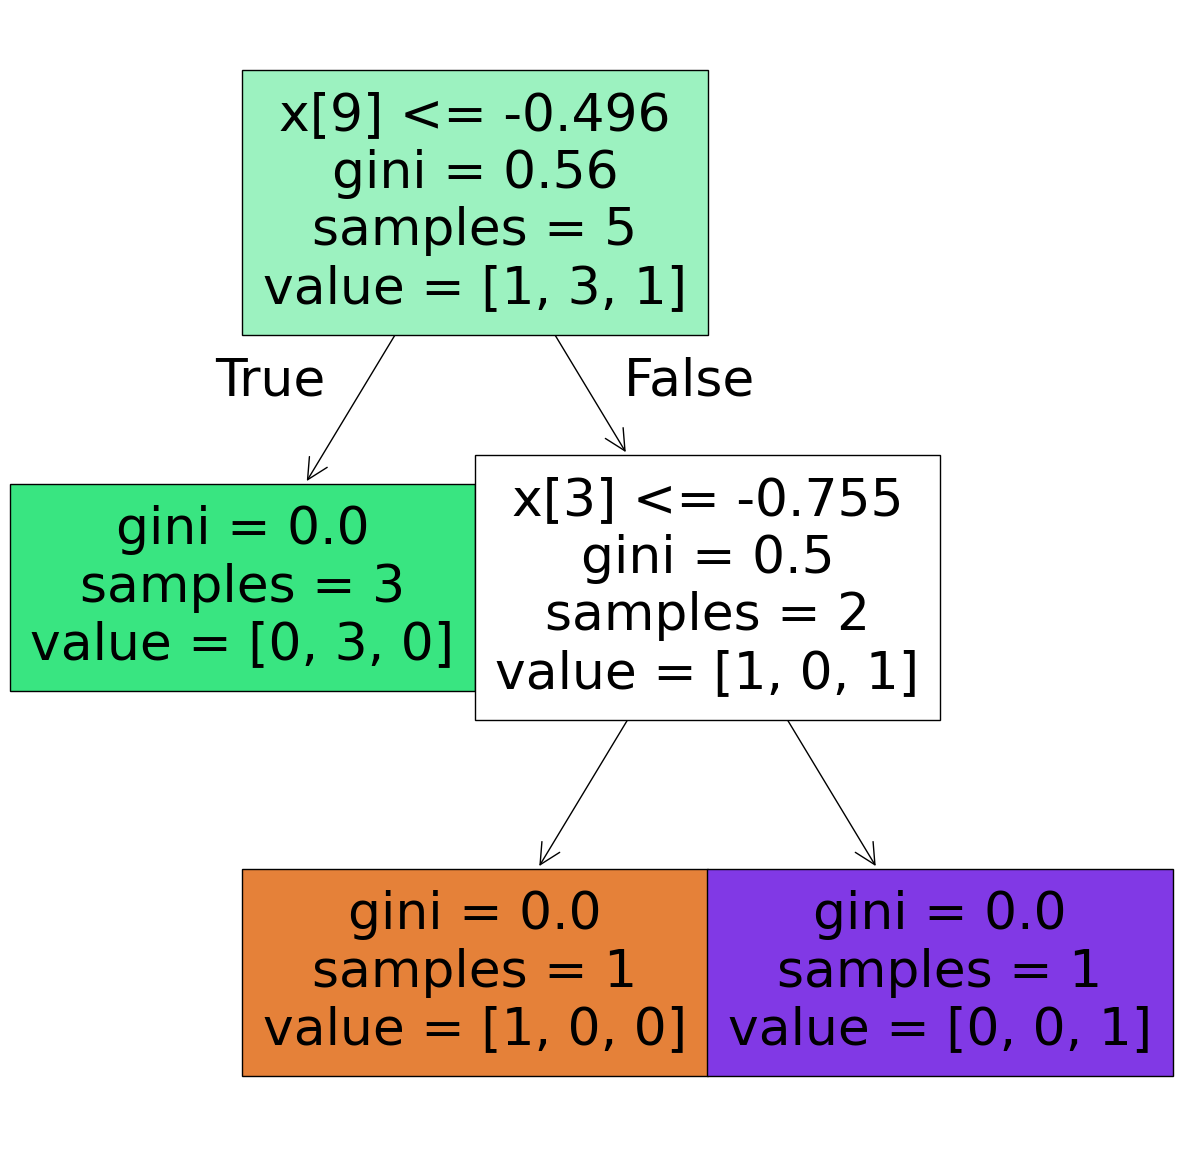

In [ ]:
from sklearn import tree
plt.figure(figsize=(15,15))
tree.plot_tree(sampleModel,filled=True)